# Experimento 7: Generación del pool de relaciones a partir de contexto real

En este notebook se construye un pool de relaciones candidatas utilizando como unidad de análisis el modelo de generación de tripletas mRebel, el cual es multilingüee.

Se ha utilizado el dataset DicatJuanRana_Dataset.csv

Las relaciones que devuelve mRebel son en ingles. Para buscar los embeddings se usa en nombre en inglés.

mRebel a partir del sujeto, relación y objeto también devuelve el tipo de sujeto y de objeto. Esto será usado para encontrar los embeddings de una relación.

Para saber el nombre de la relación en español se han utilizado dos métodos: Un modelo de traducción y llamadas a un llm (grok).

Se utiliza el algoritmo HDBSCAN para clusterizar los embeddings represntativos de las etiquetas.

Para cada cluster encontrado se realiza la busqueda del medoide para encontrar la relación más representativa. El medoide es el punto cuya distancia media al resto es mínima.

Por ello, en este experimento se utiliza:

- modelo mRebel,
- modelo de trtaducción
- llm  
- embeddings semánticos del contexto,
- clustering no supervisado mediante HDBSCAN.

El objetivo es evaluar si el contexto real mejora la agrupación de verbalizaciones equivalentes y permite obtener un primer pool de relaciones candidatas para la construcción incremental de la ontología.

In [ ]:
# ============================================================
# EXPERIMENTO 
# Generación del pool de relaciones a partir de contexto real
# ============================================================
# En esta celda se centralizan los parámetros principales del
# experimento para que el notebook sea más fácil de reproducir
# y modificar.

# Identificador del experimento.
# Se usará como prefijo en los ficheros de salida.
EXPERIMENTO = "Exp07"

# Carpeta donde se guardarán los resultados generados.
OUTPUT_DIR = "../Output/experiments"

# Modelo de embeddings utilizado para representar semánticamente
# las oraciones en las que aparece cada verbo.
MODEL_EMBEDDINGS = "paraphrase-multilingual-MiniLM-L12-v2"

# Parámetros principales de HDBSCAN.
# min_cluster_size define el tamaño mínimo que debe tener un cluster.
MIN_CLUSTER_SIZE = 4

# min_samples controla la exigencia del algoritmo para considerar
# un punto como parte de una zona densa.
MIN_SAMPLES = 2

# Semilla para mantener reproducibilidad en aquellos procesos
# que puedan depender de aleatoriedad.
RANDOM_STATE = 42

In [2]:
# ============================================================
# IMPORTS
# ============================================================

import os
import re

import pandas as pd
import numpy as np

import spacy

from sentence_transformers import SentenceTransformer

import hdbscan

import matplotlib.pyplot as plt


# ============================================================
# CREACIÓN DE CARPETAS DE SALIDA
# ============================================================

# Si la carpeta Outputs no existe, se crea automáticamente.
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# CARGA DEL MODELO DE EMBEDDINGS
# ============================================================

# Modelo multilingüe utilizado para representar semánticamente
# las oraciones extraídas del corpus.
model_embeddings = SentenceTransformer(MODEL_EMBEDDINGS)


print("Configuración cargada correctamente.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Configuración cargada correctamente.


In [4]:
# ============================================================
# CARGA DEL DATASET
# ============================================================

# Ruta del dataset limpio procedente del TFM anterior.
DATASET_PATH = "../Data/DicatJuanRana_Dataset.csv"

# Carga del CSV.
df = pd.read_csv(DATASET_PATH, sep=";")

print("Dataset cargado correctamente.")
print(f"Número de registros: {len(df)}")
print(f"Número de columnas: {df.shape[1]}")

# Mostrar primeras filas.
df.head()

#print(df_text.loc[0, "clarified_sentences"])



Dataset cargado correctamente.
Número de registros: 38
Número de columnas: 4


,year,text,sentences,clarified_sentences
0,0,"Aunque su verdadero nombre era Cosme Pérez, fu...","[""Aunque su verdadero nombre era Cosme Pérez, ...","[""Aunque su verdadero nombre era Cosme Pérez, ..."
1,1617,"Según Cotarelo , a quien sigue Sáez Raposo , C...","['Según Cotarelo, a quien sigue Sáez Raposo, ...","['Según Cotarelo, a quien sigue Sáez Raposo, S..."
2,1621,Consta la lista de la compañía de Juan Bautist...,['Consta la lista de la compañía de Juan Bauti...,['Consta la lista de la compañía de Juan Bauti...
3,1624,Cosme Pérez aparece en la nómina de la compañí...,['Cosme Pérez aparece en la nómina de la compa...,['Cosme Pérez aparece en la nómina de la compa...
4,1634,"Según Cotarelo, Cosme Pérez pertenecía a la co...","['Según Cotarelo, Cosme Pérez pertenecía a la ...","['Según Cotarelo, Cosme Pérez pertenecía a la ..."


In [5]:
# ============================================================
# SELECCIÓN DE LA COLUMNA TEXTUAL
# ============================================================
# Para este experimento utilizamos la columna clarified_sentences,
# ya que contiene las frases clarificadas del dataset limpio.

TEXT_COLUMN = "clarified_sentences"

# Comprobamos cuántos valores nulos hay en la columna seleccionada.
num_nulls = df[TEXT_COLUMN].isna().sum()

print(f"Columna textual seleccionada: {TEXT_COLUMN}")
print(f"Valores nulos en la columna: {num_nulls}")

# Nos quedamos únicamente con los registros que tienen texto válido.
df_text = df.dropna(subset=[TEXT_COLUMN]).copy()

print(f"Número de registros con texto válido: {len(df_text)}")

df_text[[TEXT_COLUMN]].head()

Columna textual seleccionada: clarified_sentences
Valores nulos en la columna: 0
Número de registros con texto válido: 38


,clarified_sentences
0,"[""Aunque su verdadero nombre era Cosme Pérez, ..."
1,"['Según Cotarelo, a quien sigue Sáez Raposo, S..."
2,['Consta la lista de la compañía de Juan Bauti...
3,['Cosme Pérez aparece en la nómina de la compa...
4,"['Según Cotarelo, Cosme Pérez pertenecía a la ..."


In [5]:
print(df_text.loc[0, TEXT_COLUMN])

["Aunque su verdadero nombre era Cosme Pérez, Cosme Pérez fue conocido artísticamente como 'Juan Rana', según documenta ya la Genealogía —este apodo ya se le aplicaba en 1636—.", 'Aunque Cotarelo aventuró que pudo haber nacido en Madrid, hoy sabemos que Cosme Pérez nació en Tudela de Duero (Valladolid), en cuya iglesia parroquial Cosme Pérez fue bautizado el 7 de abril de 1593.', 'Cosme Pérez fue hijo de Damián Pérez e Isabel de Basto, su segunda esposa, y fue el cuarto de una familia de cuatro hermanos.', 'Según algunas fuentes, como Sánchez Arjona y Subirá, Cosme Pérez estuvo casado con una actriz llamada Bernarda Ramírez.', "Por su lado, Rennert puso en duda el matrimonio de Cosme Pérez con Bernarda Ramírez y creyó más probable que Cosme Pérez estuviese casado con Bernarda Manuela ['la Grifona'], que sería, según esto, la primera mujer de Cosme Pérez.", 'Sin embargo, ambos matrimonios no se encuentran documentados, como ya puso de relieve Cotarelo, y probablemente las deducciones so

In [6]:
# ============================================================
# SEPARACIÓN DE LOS TEXTOS EN FRASES SEPARADAS
# ============================================================

import ast

sentences_data = []

for doc_id, row in df_text.iterrows():

    sentences = row[TEXT_COLUMN]


    # Asegurar lista
    if isinstance(sentences, str):
        sentences = ast.literal_eval(sentences)

    for sent_id, sent in enumerate(sentences):

        sent = sent.strip()

        if sent:

            sentences_data.append({
                "document_id": doc_id,
                "sentence_id": sent_id,
                "sentence": sent
            })

df_sentences = pd.DataFrame(sentences_data)

df_sentences = df_sentences.sort_values(
    by="document_id"
)

#df_sentences.shape
#df_sentences.info()
#df_sentences.head()
##df_sentences[df_sentences["document_id"] == 0].head(10)

print(df_sentences.loc[0, "sentence"])



Aunque su verdadero nombre era Cosme Pérez, Cosme Pérez fue conocido artísticamente como 'Juan Rana', según documenta ya la Genealogía —este apodo ya se le aplicaba en 1636—.


In [9]:
# ============================================================
# EJEMPLO LLAMADA AL MODELO MREBEL - MULTILINGÜE
# ============================================================

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

def extract_mrebel_triplets(text):
    triplets = []

    text = (
        text.replace("<s>", "")
            .replace("</s>", "")
            .replace("<pad>", "")
            .replace("tp_XX", "")
            .strip()
    )

    parts = text.split("<triplet>")

    for part in parts:
        part = part.strip()
        if not part:
            continue

        match = re.match(
            r"(.+?)\s+<([^>]+)>\s+(.+?)\s+<([^>]+)>\s+(.+)",
            part
        )

        if match:
            head, head_type, tail, tail_type, relation = match.groups()

            triplets.append({
                "head": head.strip(),
                "head_type": head_type.strip(),
                "tail": tail.strip(),
                "tail_type": tail_type.strip(),
                "type": relation.strip()
            })

    return triplets
    

# Load model and tokenizer
#tokenizer = AutoTokenizer.from_pretrained("Babelscape/mrebel-large")
tokenizer = AutoTokenizer.from_pretrained(
    "Babelscape/mrebel-large",
    src_lang="es_XX",
    tgt_lang="tp_XX"
)
model = AutoModelForSeq2SeqLM.from_pretrained("Babelscape/mrebel-large")
gen_kwargs = {
    "max_length": 256,
    "length_penalty": 0,
    "num_beams": 3,
    "num_return_sequences": 3,
}

# Text to extract triplets from
text = 'Cosme Pérez fue conocido artísticamente como Juan Rana'

# Tokenizer text
model_inputs = tokenizer(text, max_length=256, padding=True, truncation=True, return_tensors = 'pt')

generated_tokens = model.generate(
    model_inputs["input_ids"].to(model.device),
    attention_mask=model_inputs["attention_mask"].to(model.device),
    forced_bos_token_id=tokenizer.convert_tokens_to_ids("tp_XX"),
    max_length=256,
    length_penalty=0,
    num_beams=3,
    num_return_sequences=3
)

# Extract text
decoded_preds = tokenizer.batch_decode(generated_tokens, skip_special_tokens=False)

for idx, pred in enumerate(decoded_preds):
    print("="*80)
    print(f"PREDICCIÓN {idx}")
    print(pred)

# Extract triplets
for idx, sentence in enumerate(decoded_preds):
    print(f'Prediction triplets sentence {idx}')
    print(extract_mrebel_triplets(sentence))





Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

PREDICCIÓN 0
<s>tp_XX<triplet> Juan Rana <per> Cosme Pérez <per> performer</s>
PREDICCIÓN 1
<s>tp_XX<triplet> Juan Rana <per> Cosme Pérez <per> relative</s><pad>
PREDICCIÓN 2
<s>tp_XX<triplet> Juan Rana <per> Cosme Pérez <per> different from</s>
Prediction triplets sentence 0
[{'head': 'Juan Rana', 'head_type': 'per', 'tail': 'Cosme Pérez', 'tail_type': 'per', 'type': 'performer'}]
Prediction triplets sentence 1
[{'head': 'Juan Rana', 'head_type': 'per', 'tail': 'Cosme Pérez', 'tail_type': 'per', 'type': 'relative'}]
Prediction triplets sentence 2
[{'head': 'Juan Rana', 'head_type': 'per', 'tail': 'Cosme Pérez', 'tail_type': 'per', 'type': 'different from'}]


In [7]:
# ============================================================
# CONFIGURACION MODELO MREBEL - MULTILINGÜE
# ============================================================

import pandas as pd
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer



# Load model and tokenizer - spanish
tokenizer = AutoTokenizer.from_pretrained(
    "Babelscape/mrebel-large",
    src_lang="es_XX",
    tgt_lang="tp_XX"
)

# explora 3 posibles generaciones y devuelve las 3 mejores
model = AutoModelForSeq2SeqLM.from_pretrained("Babelscape/mrebel-large")
gen_kwargs = {
    "max_length": 256,
    "length_penalty": 0,
    "num_beams": 3, 
    "num_return_sequences": 3,
}

def extract_mrebel_triplets(text):
    triplets = []

    text = (
        text.replace("<s>", "")
            .replace("</s>", "")
            .replace("<pad>", "")
            .replace("tp_XX", "")
            .strip()
    )

    parts = text.split("<triplet>")

    for part in parts:
        part = part.strip()
        if not part:
            continue

        match = re.match(
            r"(.+?)\s+<([^>]+)>\s+(.+?)\s+<([^>]+)>\s+(.+)",
            part
        )

        if match:
            head, head_type, tail, tail_type, relation = match.groups()

            triplets.append({
                "head": head.strip(),
                "head_type": head_type.strip(),
                "tail": tail.strip(),
                "tail_type": tail_type.strip(),
                "type": relation.strip()
            })

    return triplets


def get_mrebel_triplets_for_sentence(text):
    model_inputs = tokenizer(
        text,
        max_length=256,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    generated_tokens = model.generate(
        model_inputs["input_ids"].to(model.device),
        attention_mask=model_inputs["attention_mask"].to(model.device),
        forced_bos_token_id=tokenizer.convert_tokens_to_ids("tp_XX"),
        max_length=256,
        length_penalty=0,
        num_beams=3,
        num_return_sequences=3
    )

    decoded_preds = tokenizer.batch_decode(
        generated_tokens,
        skip_special_tokens=False
    )

    triplets = [
        extract_mrebel_triplets(pred)
        for pred in decoded_preds
    ]

    return triplets

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# EJECUCION DEL MODEL MREBEL PARA SACAR LAS TRIPLETAS DE CADA FRASE
# ============================================================

df_sentences["mrebel_outputs"] = df_sentences["sentence"].apply(
    get_mrebel_triplets_for_sentence
)



In [ ]:
# ============================================================
# GUARDAR DATAFTAME df_sentences A FICHERO
# ============================================================

from datetime import datetime

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

filename = (
    f"{OUTPUT_DIR}/df_sentences_mrebel_{timestamp}.pkl"
)

df_sentences.to_pickle(filename)

print(f"Guardado en: {filename}")


Guardado en: ../Output/experiments/df_sentences_mrebel_20260517_091524.pkl


In [87]:
df_sentences.head()

,document_id,sentence_id,sentence,mrebel_outputs,triplets_merged
0,0,0,"Aunque su verdadero nombre era Cosme Pérez, Co...","[[{'head': 'Juan Rana', 'head_type': 'per', 't...","[{'head': 'Juan Rana', 'head_type': 'per', 'ta..."
1,0,1,Aunque Cotarelo aventuró que pudo haber nacido...,"[[{'head': 'Tudela de Duero', 'head_type': 'lo...","[{'head': 'Tudela de Duero', 'head_type': 'loc..."
2,0,2,Cosme Pérez fue hijo de Damián Pérez e Isabel ...,"[[{'head': 'Damián Pérez', 'head_type': 'per',...","[{'head': 'Damián Pérez', 'head_type': 'per', ..."
3,0,3,"Según algunas fuentes, como Sánchez Arjona y S...","[[{'head': 'Cosme Pérez', 'head_type': 'per', ...","[{'head': 'Cosme Pérez', 'head_type': 'per', '..."
4,0,4,"Por su lado, Rennert puso en duda el matrimoni...","[[{'head': 'Cosme Pérez', 'head_type': 'per', ...","[{'head': 'Cosme Pérez', 'head_type': 'per', '..."


In [ ]:
# ============================================================
# LEER DATAFTAME df_sentences DE FICHERO
# ============================================================

df_sentences = pd.read_pickle(
    f"{OUTPUT_DIR}/df_sentences_mrebel_20260517_091524.pkl"
)

In [ ]:
# ============================================================
# SELECCION DE LAS TRIPLETAS UNICAS PARA CADA FRASE
# ============================================================

def merge_unique_triplets(predictions):

    all_triplets = []

    # Unimos todas las tripletas de las 3 predicciones
    for pred in predictions:
        all_triplets.extend(pred)

    # Eliminamos duplicados
    unique_triplets = {
        (
            t["head"],
            t["head_type"],
            t["tail"],
            t["tail_type"],
            t["type"]
        ): t
        for t in all_triplets
    }

    return list(unique_triplets.values())

df_sentences["triplets_merged"] = df_sentences[
    "mrebel_outputs"
].apply(merge_unique_triplets)

In [12]:
## print(df_sentences.loc[0, "sentence"])
## print(df_sentences.loc[0, "triplets_merged"])
df_sentences.columns

Index(['document_id', 'sentence_id', 'sentence', 'mrebel_outputs',
       'triplets_merged'],
      dtype='object')

In [13]:
# ============================================================
# CREACION DATAFRAME df_triplets CON TODAS LAS TRIPLETAS OBTENIDAS
# ============================================================

triplet_rows = []

for _, row in df_sentences.iterrows():

    triplets = row["triplets_merged"]

    for triplet in triplets:

        triplet_rows.append({
            "document_id": row["document_id"],
            "sentence_id": row["sentence_id"],
            "sentence": row["sentence"],
            "head": triplet.get("head"),
            "head_type": triplet.get("head_type"),
            "tail": triplet.get("tail"),
            "tail_type": triplet.get("tail_type"),
            "relation": triplet.get("type")
        })

df_triplets = pd.DataFrame(triplet_rows)

df_triplets.head()

,document_id,sentence_id,sentence,head,head_type,tail,tail_type,relation
0,0,0,"Aunque su verdadero nombre era Cosme Pérez, Co...",Juan Rana,per,Cosme Pérez,per,said to be the same as
1,0,0,"Aunque su verdadero nombre era Cosme Pérez, Co...",Juan Rana,per,Cosme Pérez,per,different from
2,0,0,"Aunque su verdadero nombre era Cosme Pérez, Co...",Cosme Pérez,per,Cosme Pérez,per,different from
3,0,1,Aunque Cotarelo aventuró que pudo haber nacido...,Tudela de Duero,loc,Valladolid,loc,located in the administrative territorial entity
4,0,1,Aunque Cotarelo aventuró que pudo haber nacido...,Cosme Pérez,per,Tudela de Duero,loc,place of birth


In [14]:
print(f"Número total de tripletas: {len(df_triplets)}")

Número total de tripletas: 1111


In [ ]:
# ============================================================
# CREACION EN df_triplets DE DOS COLUMNAS PARA GUARDAR EL NOMBRE LARGO DEL TIPO DE ENTIDAD DEVUELTO POR MREBEL
# ============================================================

entity_type_map = {
    "per": "person",
    "loc": "location",
    "org": "organization",
    "date": "date",
    "time": "time",
    "event": "event",
    "misc": "miscellaneous",
    "prod": "product",
    "animal": "animal",
    "disease": "disease",
    "food": "food",
    "language": "language",
    "law": "law",
    "money": "money",
    "nationality": "nationality",
    "facility": "facility",
    "gpe": "geopolitical entity",
    "work_of_art": "work of art",
    "quantity": "quantity",
    "ordinal": "ordinal",
    "cardinal": "cardinal",
    "percent": "percentage",
    "person": "person",
    "location": "location",
    "organization": "organization"
}

df_triplets["head_type_full"] = (
    df_triplets["head_type"]
    .str.lower()
    .map(entity_type_map)
    .fillna(df_triplets["head_type"])
)

df_triplets["tail_type_full"] = (
    df_triplets["tail_type"]
    .str.lower()
    .map(entity_type_map)
    .fillna(df_triplets["tail_type"])
)

In [16]:
# ============================================================
# CREACION TEXTO CON EL QUE SE OBTENDRAN LOS EMBEDDINGS
# ============================================================

# Para obtener el embedding se añade a la relación el nombre completo del sujeto y del objeto
df_triplets["texto_embedding"] = (
    df_triplets["head_type_full"] + " " +
    df_triplets["relation"] + " " +
    df_triplets["tail_type_full"]
)

df_triplets.head()
#df_triplets.shape

,document_id,sentence_id,sentence,head,head_type,tail,tail_type,relation,head_type_full,tail_type_full,texto_embedding
0,0,0,"Aunque su verdadero nombre era Cosme Pérez, Co...",Juan Rana,per,Cosme Pérez,per,said to be the same as,person,person,person said to be the same as person
1,0,0,"Aunque su verdadero nombre era Cosme Pérez, Co...",Juan Rana,per,Cosme Pérez,per,different from,person,person,person different from person
2,0,0,"Aunque su verdadero nombre era Cosme Pérez, Co...",Cosme Pérez,per,Cosme Pérez,per,different from,person,person,person different from person
3,0,1,Aunque Cotarelo aventuró que pudo haber nacido...,Tudela de Duero,loc,Valladolid,loc,located in the administrative territorial entity,location,location,location located in the administrative territo...
4,0,1,Aunque Cotarelo aventuró que pudo haber nacido...,Cosme Pérez,per,Tudela de Duero,loc,place of birth,person,location,person place of birth location


In [29]:
# ============================================================
# OBTENCION EMBEDDINGS
# ============================================================

texts = df_triplets["texto_embedding"].tolist()

embeddings = model_embeddings.encode(
    texts,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embeddings generados correctamente.")
print(f"Número de embeddings: {embeddings.shape[0]}")
print(f"Dimensión de cada embedding: {embeddings.shape[1]}")

df_triplets["embedding"] = list(embeddings)



Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Embeddings generados correctamente.
Número de embeddings: 1111
Dimensión de cada embedding: 384


In [17]:
# ============================================================
# CONFIGURACION MODELO PARA OBTENER LA TRADUCCION AL ESPAÑOL DE LA RELACION
# ============================================================

from transformers import MarianMTModel, MarianTokenizer

translator_tokenizer = MarianTokenizer.from_pretrained(
    "Helsinki-NLP/opus-mt-en-es"
)

translator_model = MarianMTModel.from_pretrained(
    "Helsinki-NLP/opus-mt-en-es"
)


def translate_text(text):

    inputs = translator_tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )

    translated_tokens = translator_model.generate(
        **inputs,
        max_length=128
    )

    return translator_tokenizer.decode(
        translated_tokens[0],
        skip_special_tokens=True
    )





c:\Users\xavie\anaconda3\envs\spacy_env\lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# METODOS PARA OBTENER LA TRADUCCION AL ESPAÑOL DE LA RELACION
# ============================================================

# Para obtener la relacion se crean una marcas ficticias para aislar la relacion
def extract_between_markers(text):
    start = "AAA"
    end = "BBB"

    if start in text and end in text:
        return text.split(start, 1)[1].split(end, 1)[0].strip(" .,:;")

    return text.strip(" .,:;")
    
def translate_relation_with_model_with_marks(row):

    text = (
        f"In a knowledge graph, a {row['head_type_full']} entity "
        f"AAA {row['relation']} BBB "
        f"a {row['tail_type_full']} entity."
    )

    translated = translate_text(text)

    return extract_between_markers(translated)

In [ ]:
# ============================================================
# OBTENCION TRADUCCION AL ESPAÑOL DE LA RELACION CON MODELO TRADUCTOR
# ============================================================

import time

inicio = time.time()

df_triplets["relation_es_translator_marks"] = df_triplets.apply(
    translate_relation_with_model_with_marks,
    axis=1
)

fin = time.time()

tiempo = fin - inicio

minutos = int(tiempo // 60)
segundos = tiempo % 60

print(f"Tiempo de ejecución: {minutos} min {segundos:.2f} s")

In [ ]:
#df_triplets.head(5)
print(df_triplets.loc[10, "relation_es_translator_marks"])

In [ ]:
# ============================================================
# CONFIGURACION GROQ API (LLM) PARA OBTENCION TRADUCCION AL ESPAÑOL DE LA RELACION
# ============================================================

from openai import OpenAI

client = OpenAI(
    api_key="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",
    base_url="https://api.groq.com/openai/v1"
)

In [15]:
# ============================================================
# LLAMADA AL LLM
# ============================================================

def call_llm(prompt):

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    return response.choices[0].message.content.strip()


def translate_relation_llm(row):

    prompt = f"""
Translate the following ontology relation into concise Spanish.

Subject type: {row['head_type_full']}
Relation: {row['relation']}
Object type: {row['tail_type_full']}

Return ONLY the Spanish relation label.
"""

    return call_llm(prompt)

In [ ]:
# ============================================================
# OBTENCION TRADUCCION AL ESPAÑOL DE LA RELACION CON LLM
# ============================================================

import time

inicio = time.time()

df_triplets["relation_es_llm"] = df_triplets.apply(
    translate_relation_llm,
    axis=1
)

fin = time.time()

tiempo = fin - inicio

minutos = int(tiempo // 60)
segundos = tiempo % 60

print(f"Tiempo de ejecución: {minutos} min {segundos:.2f} s")

In [22]:
print(df_triplets.loc[10, "relation_es_llm"])

Cónyuge


In [39]:
# ============================================================
# GUARDAR DATAFTAME df_triplets A FICHERO
# ============================================================
from datetime import datetime

timestamp = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

filename = (
    f"{OUTPUT_DIR}/df_triplets_{timestamp}.pkl"
)

df_triplets.to_pickle(filename)

print(f"Guardado en: {filename}")

Guardado en: ../Output/experiments/df_triplets_20260518_112407.pkl


In [3]:
# ============================================================
# LEER DATAFTAME df_sentences DE FICHERO
# ============================================================

df_triplets = pd.read_pickle(
    f"{OUTPUT_DIR}/df_triplets_20260518_112407.pkl"
)

embeddings = np.array(df_triplets["embedding"].tolist())

In [4]:
df_triplets.iloc[6]

document_id                                                                     0
sentence_id                                                                     2
sentence                        Cosme Pérez fue hijo de Damián Pérez e Isabel ...
head                                                                 Damián Pérez
head_type                                                                     per
tail                                                                  Cosme Pérez
tail_type                                                                     per
relation                                                                    child
head_type_full                                                             person
tail_type_full                                                             person
texto_embedding                                               person child person
embedding                       [-0.05126641, 0.039859403, 0.016299894, 0.0278...
relation_es_tran

In [4]:
# ============================================================
# CLUSTERING SEMÁNTICO CON HDBSCAN
# ============================================================
# Aplicamos HDBSCAN sobre los embeddings generados a partir
# del contexto oracional de cada relación verbal.

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean"
)

clusters = clusterer.fit_predict(embeddings)

# Añadimos los clusters al dataframe.
df_triplets["cluster"] = clusters

print("Clustering completado correctamente.")

# ============================================================
# MÉTRICAS GENERALES
# ============================================================

total_relaciones = len(df_triplets)

# Número de clusters reales (excluyendo ruido = -1)
total_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

# Número de relaciones clasificadas como ruido
total_noise = (clusters == -1).sum()

# Porcentaje de ruido
noise_percentage = round(
    total_noise / total_relaciones * 100,
    2
)

print(f"Relaciones analizadas: {total_relaciones}")
print(f"Clusters detectados: {total_clusters}")
print(f"Relaciones clasificadas como ruido: {total_noise}")
print(f"Porcentaje de ruido: {noise_percentage}%")

Clustering completado correctamente.
Relaciones analizadas: 1111
Clusters detectados: 86
Relaciones clasificadas como ruido: 129
Porcentaje de ruido: 11.61%


In [9]:
# ============================================================
# INSPECCIÓN DE CLUSTERS
# ============================================================
# Mostramos las relaciones agrupadas en cada cluster
# para analizar coherencia semántica.

for cluster_id in sorted(df_triplets["cluster"].unique()):

    # Ignoramos ruido
    if cluster_id == -1:
        continue

    print("=" * 60)
    print(f"CLUSTER {cluster_id}")
    print("=" * 60)

    cluster_data = df_triplets[
        df_triplets["cluster"] == cluster_id
    ]

    relaciones_traductor = sorted(
        cluster_data["relation_es_translator_marks"].unique()
    )

    relaciones_llm = sorted(
        cluster_data["relation_es_llm"].unique()
    )

    print(f"\nRelaciones traductor: {relaciones_traductor[:30]}")
    print(f"Relaciones llm: {relaciones_llm[:30]}")

    print(f"\nNúmero de relaciones: {len(cluster_data)}")
    print(f"Número relaciones únicas traductor: {len(relaciones_traductor)}")
    print(f"Número relaciones únicas llm: {len(relaciones_llm)}")

    print("\n")

CLUSTER 0

Relaciones traductor: ['causa de muerte', 'lugar de entierro', 'lugar de la muerte', 'tipo de muerte']
Relaciones llm: ['Causa de muerte.', 'Circunstancia de muerte', 'Lugar de entierro.', 'Lugar de fallecimiento.']

Número de relaciones: 20
Número relaciones únicas traductor: 4
Número relaciones únicas llm: 4


CLUSTER 1

Relaciones traductor: ['fecha de la muerte', 'fecha de nacimiento']
Relaciones llm: ['Fecha de fallecimiento', 'Fecha de nacimiento']

Número de relaciones: 7
Número relaciones únicas traductor: 2
Número relaciones únicas llm: 2


CLUSTER 2

Relaciones traductor: ['adoraba a', 'religión']
Relaciones llm: ['Adorada por', 'Persona practica religión.']

Número de relaciones: 4
Número relaciones únicas traductor: 2
Número relaciones únicas llm: 2


CLUSTER 3

Relaciones traductor: ['socio en negocio o deporte', 'socio en negocios o deportes <per> Antonio García de Prado <per> socio en negocios o deportes']
Relaciones llm: ['Colaborador', 'Socio en negocios o d

In [10]:
pd.set_option("display.max_colwidth", None)


In [11]:
df_triplets[
    df_triplets["cluster"] == 14
][[
    "sentence",
    "relation_es_translator_marks",
    "relation_es_llm",
    "relation",
    "head",
    "tail"

]]

,sentence,relation_es_translator_marks,relation_es_llm,relation,head,tail
123,"El manuscrito incluye un reparto de actores en el que figura ""Cosme Pérez"", probablemente Cosme Pérez, en el papel de ""Espinel"".",niño,Padre,child,Cosme Pérez,Cosme Pérez
375,"El escándalo empezó hacia el 18 de octubre con la detención de un tal Agustín Merlo por mantener una reyerta con el hijo de un músico de la capilla real llamado Valdés, quien acusó a Agustín Merlo de haberle requerido sexualmente.",niño,Padre,child,Agustín Merlo,Agustín Merlo
376,"El escándalo empezó hacia el 18 de octubre con la detención de un tal Agustín Merlo por mantener una reyerta con el hijo de un músico de la capilla real llamado Valdés, quien acusó a Agustín Merlo de haberle requerido sexualmente.",niño,Padre,child,Agustín Merlo,Valdés
543,"El 15 de noviembre, día en que Mariana de Austria hacía su entrada en Madrid como nueva reina, Cosme Pérez, por mediación de su personaje Juan Rana, hizo llegar a Mariana de Austria un memorial titulado Memorial que dio Juan Rana a la Reina Nuestra Señora Doña Mariana de Austria en su entrada en esta corte antes de llegar a Palacio.",niño,Padre,child,Mariana de Austria,Mariana de Austria
545,"En el memorial, Cosme Pérez solicitaba la concesión de algún oficio palaciego a su hija para, de esta manera, paliar la difícil situación económica de su hija y aumentar las posibilidades de contraer matrimonio de su hija.",niño,Padre,child,Cosme Pérez,su hija
566,"Cosme Pérez 'Juan Rana' figura también entre los miembros de una lista de la compañía de Antonio García de Prado ""Prado farsante"" que apareció publicada por Cruzada Villaamil junto con varias noticias de representaciones particulares hechas al Rey en 1623 por la compañía de Antonio de Prado —pero es imposible que esta lista sea de 1623, ya que incluye a José Antonio de Prado, que nació en 1635.",niño,Padre,child,Antonio García de Prado,José Antonio de Prado
574,"Consta una comunicación, fechada en el real Sitio del Buen Retiro el 26 de abril, del Duque de Nájera al grefier de la Reina Simón de Alcántara, por la que el Duque de Nájera informa al grefier de la Reina Simón de Alcántara:",niño,Padre,child,Simón de Alcántara,Simón de Alcántara
604,"y también con motivo del cumpleaños de la Reina Mariana de Austria y de su recuperación del ""accidente que le sobrevino estando el Rey Nuestro Señor en las Descalzas,",niño,Padre,child,Reina Mariana de Austria,Reina Mariana de Austria
605,"Con motivo del parto del primer hijo de la reina Mariana de Austria, la infanta Margarita,",niño,Padre,child,Mariana de Austria,Margarita
606,"Con motivo del parto del primer hijo de la reina Mariana de Austria, la infanta Margarita,",niño,Padre,child,Mariana de Austria,infanta Margarita


In [12]:
pd.reset_option("display.max_colwidth")

In [13]:
# ============================================================
# MÉTRICAS BÁSICAS DE CLUSTERS
# ============================================================
# Calculamos métricas básicas para analizar el comportamiento
# de los clusters generados por HDBSCAN.

cluster_metrics = []

# Recorremos todos los clusters excepto ruido (-1).
for cluster_id in sorted(df_triplets["cluster"].unique()):

    if cluster_id == -1:
        continue

    cluster_data = df_triplets[
        df_triplets["cluster"] == cluster_id
    ]

    # Número total de relaciones en el cluster.
    total_relaciones_cluster = len(cluster_data)


     # Número de relaciones únicas.
    relaciones_unicas = cluster_data["relation"].nunique()

    # Frecuencia media de reutilización con traductor.
    frecuencia_media = (
        total_relaciones_cluster / relaciones_unicas
    )

    # Lista de relaciones del cluster.
    lista_relaciones = sorted(
        cluster_data["relation"].unique()
    )

    cluster_metrics.append({
        "cluster": cluster_id,
        "num_relaciones": total_relaciones_cluster,
        "num_relaciones_unicas": relaciones_unicas,
        "frecuencia_media": round(frecuencia_media, 2),
        "relaciones": ", ".join(lista_relaciones[:100])
    })

# Convertimos a dataframe.
df_cluster_metrics = pd.DataFrame(cluster_metrics)

# Ordenamos por tamaño del cluster.
df_cluster_metrics = df_cluster_metrics.sort_values(
    by="num_relaciones",
    ascending=False
).reset_index(drop=True)

print("Métricas de clusters calculadas correctamente.")

df_cluster_metrics.head(10)

Métricas de clusters calculadas correctamente.


,cluster,num_relaciones,num_relaciones_unicas,frecuencia_media,relaciones
0,50,84,1,84.0,author
1,39,51,1,51.0,relative
2,58,38,1,38.0,significant person
3,25,36,1,36.0,located in the administrative territorial entity
4,54,32,1,32.0,spouse
5,64,30,1,30.0,occupation
6,26,27,1,27.0,located in the administrative territorial entity
7,61,27,1,27.0,notable work
8,15,22,1,22.0,child
9,55,22,1,22.0,spouse


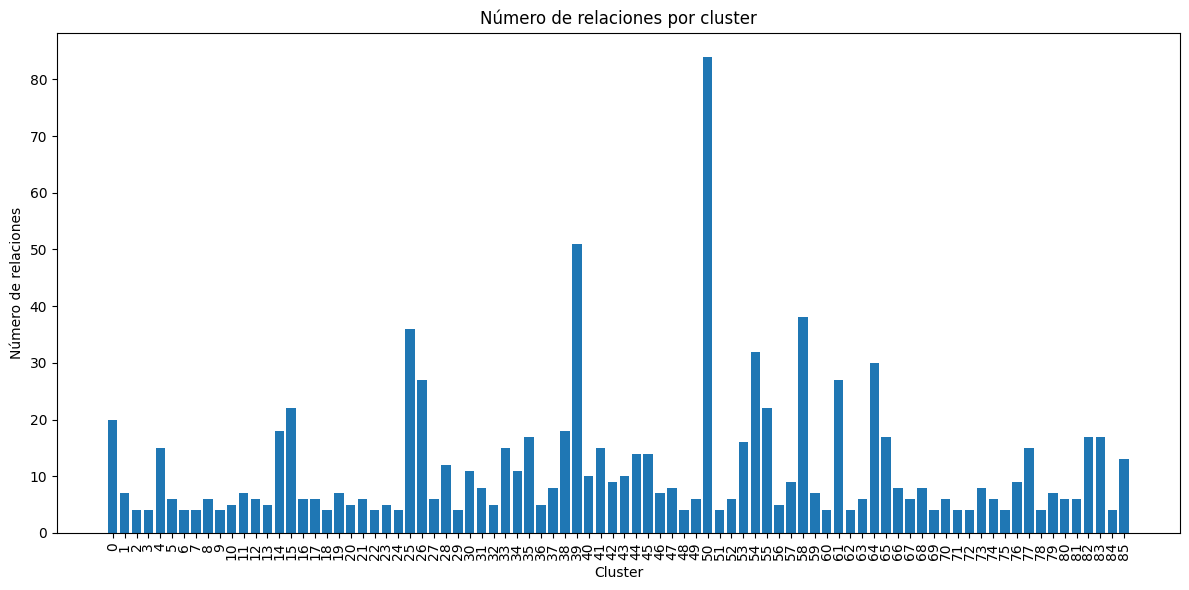

In [14]:
# ============================================================
# TAMAÑO DE LOS CLUSTERS
# ============================================================
# Visualización del número de relaciones detectadas
# en cada cluster generado por HDBSCAN.

# Ordenamos clusters por tamaño.
df_plot = df_cluster_metrics.sort_values(
    by="cluster",
    ascending=True
)

plt.figure(figsize=(12, 6))

plt.bar(
    df_plot["cluster"].astype(str),
    df_plot["num_relaciones"]
)

plt.title("Número de relaciones por cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de relaciones")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# COHERENCIA SEMÁNTICA INTRA-CLUSTER
# ============================================================
# Calculamos la similitud media entre los embeddings de cada cluster.
#
# Importante:
# Cada embedding se asocia explícitamente a su fila correspondiente
# para evitar desalineaciones entre índices del dataframe y posiciones
# del array de embeddings.

from sklearn.metrics.pairwise import cosine_similarity

# Guardamos cada embedding dentro del dataframe de relaciones.
# Esto garantiza que cada fila conserva su representación vectorial.

cluster_coherence = []

for cluster_id in sorted(df_triplets["cluster"].unique()):

    # Ignoramos el ruido.
    if cluster_id == -1:
        continue

    # Filtramos las relaciones pertenecientes al cluster actual.
    cluster_data = df_triplets[
        df_triplets["cluster"] == cluster_id
    ]

    # Recuperamos los embeddings asociados a esas filas.
    cluster_embeddings = np.vstack(
        cluster_data["embedding"].values
    )

    # Si el cluster tiene menos de 2 elementos, no se puede calcular coherencia.
    if len(cluster_embeddings) < 2:
        coherence = np.nan
    else:
        sim_matrix = cosine_similarity(cluster_embeddings)

        # Extraemos solo la parte superior de la matriz, excluyendo la diagonal.
        # Así evitamos comparar cada embedding consigo mismo.
        sim_values = sim_matrix[
            np.triu_indices_from(sim_matrix, k=1)
        ]

        coherence = sim_values.mean()

    cluster_coherence.append({
        "cluster": cluster_id,
        "coherencia_semantica": coherence
    })

df_cluster_coherence = pd.DataFrame(cluster_coherence)

# Eliminamos una posible columna previa de coherencia si la celda se reejecuta.
df_cluster_metrics = df_cluster_metrics.drop(
    columns=["coherencia_semantica"],
    errors="ignore"
)

# Unimos la coherencia con las métricas básicas de cluster.
df_cluster_metrics = df_cluster_metrics.merge(
    df_cluster_coherence,
    on="cluster",
    how="left"
)

# Ordenamos por coherencia semántica.
df_cluster_metrics = df_cluster_metrics.sort_values(
    by="coherencia_semantica",
    ascending=True
).reset_index(drop=True)

df_cluster_metrics.head(15)


,cluster,num_relaciones,num_relaciones_unicas,frecuencia_media,relaciones,coherencia_semantica
0,30,11,6,1.83,"based on, depicts, genre, instance of, part of...",0.791641
1,16,6,4,1.50,"commemorates, facet of, part of, target",0.816367
2,2,4,2,2.00,"religion, worshipped by",0.827613
3,56,5,1,5.00,named after,0.841301
4,36,5,3,1.67,"characters, characters <org> Cosme Pérez <per>...",0.844738
5,0,20,4,5.00,"cause of death, manner of death, place of buri...",0.847535
6,1,7,2,3.50,"date of birth, date of death",0.849967
7,19,7,2,3.50,"participant, significant event",0.850700
8,31,8,2,4.00,"country, location",0.861767
9,20,5,2,2.50,located in the administrative territorial enti...,0.869321


In [16]:
df_cluster_metrics.head(15)
#df_cluster_metrics.tail(15)

,cluster,num_relaciones,num_relaciones_unicas,frecuencia_media,relaciones,coherencia_semantica
0,30,11,6,1.83,"based on, depicts, genre, instance of, part of...",0.791641
1,16,6,4,1.50,"commemorates, facet of, part of, target",0.816367
2,2,4,2,2.00,"religion, worshipped by",0.827613
3,56,5,1,5.00,named after,0.841301
4,36,5,3,1.67,"characters, characters <org> Cosme Pérez <per>...",0.844738
5,0,20,4,5.00,"cause of death, manner of death, place of buri...",0.847535
6,1,7,2,3.50,"date of birth, date of death",0.849967
7,19,7,2,3.50,"participant, significant event",0.850700
8,31,8,2,4.00,"country, location",0.861767
9,20,5,2,2.50,located in the administrative territorial enti...,0.869321


In [ ]:
# ============================================================
# BUSQUEDA PARA CADA CLUSTER DEL MEDOID
# ============================================================

## eL MEDOID ES el embedding cuya distancia media al resto es mínima

import numpy as np
from sklearn.metrics.pairwise import cosine_distances


def assign_cluster_medoids(df_triplets):
    """
    Añade una columna 'relation_elected' al dataframe.
    
    - 'SI'  -> relación medoid del cluster
    - 'NO'  -> resto de relaciones del cluster
    - ruido (-1) -> siempre 'SI'
    
    Requiere:
    - columna 'embedding'
    - columna 'cluster'
    """

    # Inicializar columna
    df_triplets["relation_elected"] = "NO"

    # Obtener clusters únicos
    clusters = df_triplets["cluster"].unique()

    for cluster_id in clusters:

        # Caso ruido
        if cluster_id == -1:
            df_triplets.loc[
                df_triplets["cluster"] == -1,
                "relation_elected"
            ] = "SI"

            continue

        # Filas del cluster
        cluster_df = df_triplets[
            df_triplets["cluster"] == cluster_id
        ]

        # Obtener embeddings
        embeddings = np.array(
            cluster_df["embedding"].tolist()
        )

        # Calcular matriz de distancias coseno
        dist_matrix = cosine_distances(embeddings)

        # Distancia media de cada embedding al resto
        avg_distances = dist_matrix.mean(axis=1)

        # Índice del medoid (mínima distancia media)
        medoid_local_idx = np.argmin(avg_distances)

        # Índice real dentro del dataframe original
        medoid_global_idx = cluster_df.index[medoid_local_idx]

        # Marcar medoid como SI
        df_triplets.loc[
            medoid_global_idx,
            "relation_elected"
        ] = "SI"

    return df_triplets

df_triplets = assign_cluster_medoids(df_triplets)

In [18]:
num_relations_selected = (
    df_triplets["relation_elected"] == "SI"
).sum()

print(num_relations_selected)

215


In [20]:
df_triplets.columns

Index(['document_id', 'sentence_id', 'sentence', 'head', 'head_type', 'tail',
       'tail_type', 'relation', 'head_type_full', 'tail_type_full',
       'texto_embedding', 'embedding', 'relation_es_translator_marks',
       'relation_es_llm', 'cluster', 'relation_elected'],
      dtype='object')

In [21]:
for cluster_id in sorted(df_triplets["cluster"].unique()):

    # Ignorar ruido
    if cluster_id == -1:
        continue

    print("=" * 60)
    print(f"CLUSTER {cluster_id}")
    print("=" * 60)

    # Datos del cluster
    cluster_data = df_triplets[
        df_triplets["cluster"] == cluster_id
    ]

    # Relaciones únicas
    relaciones_traductor = sorted(
        cluster_data["relation_es_translator_marks"].unique()
    )

    relaciones_llm = sorted(
        cluster_data["relation_es_llm"].unique()
    )

    # Relación elegida (medoid)
    relacion_elegida = cluster_data[
        cluster_data["relation_elected"] == "SI"
    ]

    # Mostrar relaciones agrupadas
    print(f"\nRelaciones traductor: {relaciones_traductor[:30]}")
    print(f"Relaciones llm: {relaciones_llm[:30]}")

    # Mostrar relación elegida
    print("\nRelación elegida:")

    for _, row in relacion_elegida.iterrows():

        print(
            f"- {row['head_type_full']} -- "
            f"{row['relation']} -- "
            f"{row['tail_type_full']} "
            f"| traductor: {row['relation_es_translator_marks']} "
            f"| llm: {row['relation_es_llm']}"
        )

    # Estadísticas
    print(f"\nNúmero de relaciones: {len(cluster_data)}")

    print(
        f"Número relaciones únicas traductor: "
        f"{len(relaciones_traductor)}"
    )

    print(
        f"Número relaciones únicas llm: "
        f"{len(relaciones_llm)}"
    )

    print("\n")

CLUSTER 0

Relaciones traductor: ['causa de muerte', 'lugar de entierro', 'lugar de la muerte', 'tipo de muerte']
Relaciones llm: ['Causa de muerte.', 'Circunstancia de muerte', 'Lugar de entierro.', 'Lugar de fallecimiento.']

Relación elegida:
- person -- place of death -- location | traductor: lugar de la muerte | llm: Lugar de fallecimiento.

Número de relaciones: 20
Número relaciones únicas traductor: 4
Número relaciones únicas llm: 4


CLUSTER 1

Relaciones traductor: ['fecha de la muerte', 'fecha de nacimiento']
Relaciones llm: ['Fecha de fallecimiento', 'Fecha de nacimiento']

Relación elegida:
- person -- date of birth -- date | traductor: fecha de nacimiento | llm: Fecha de nacimiento

Número de relaciones: 7
Número relaciones únicas traductor: 2
Número relaciones únicas llm: 2


CLUSTER 2

Relaciones traductor: ['adoraba a', 'religión']
Relaciones llm: ['Adorada por', 'Persona practica religión.']

Relación elegida:
- person -- religion -- concept | traductor: religión | llm